# 📈 Sales Forecasting for Retail Stores (Time Series Machine Learning Project)

## 🧩 Project Overview
This project aims to forecast daily sales for a retail store using historical sales data. 
Accurate forecasting helps businesses optimize inventory, staff planning, and marketing budgets.

## 🎯 Business Objectives
- Predict future sales (next 30 days)
- Identify trends and seasonal patterns
- Improve inventory & supply chain decisions

### STEP 1 -  IMPORT ALL THE LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

# ML Models
from sklearn.linear_model import LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.preprocessing import LabelEncoder

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error

### STEP 2 - LOAD THE DATASETS

In [5]:
train = pd.read_csv("data/train.csv", parse_dates=["date"])
stores = pd.read_csv("data/stores.csv")
oil = pd.read_csv("data/oil.csv", parse_dates=["date"])
holidays = pd.read_csv("data/holidays_events.csv", parse_dates=["date"])
transactions = pd.read_csv("data/transactions.csv", parse_dates=["date"])

# Ensure all date columns are datetime
train['date'] = pd.to_datetime(train['date'])
oil['date'] = pd.to_datetime(oil['date'])
holidays['date'] = pd.to_datetime(holidays['date'], format='mixed', dayfirst=True)
transactions['date'] = pd.to_datetime(transactions['date'])

# Display shapes
print("Train Shape:", train.shape)
print("Stores Shape:", stores.shape)
print("Oil Shape:", oil.shape)
print("Holidays Shape:", holidays.shape)
print("Transactions Shape:", transactions.shape)

train.head()

Train Shape: (3000888, 6)
Stores Shape: (54, 5)
Oil Shape: (1218, 2)
Holidays Shape: (350, 6)
Transactions Shape: (83488, 3)


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


### STEP 3 - DATA CLEANING & MERGING
We will:
- Clean oil prices (interpolate missing values)
- Clean holidays (remove irrelevant holiday types)
- Merge all datasets
- Remove negative/garbage sales
- Fill missing values
- Sort data properly

#### 1. CLEAN OIL PRICE

In [8]:
oil['dcoilwtico'] = oil['dcoilwtico'].interpolate()   # fill missing values

#### 2. CLEAN HOLIDAYS

In [10]:
# Remove transferred or work-day adjustments (to reduce noise)
holidays = holidays[holidays['transferred'] == False]

# Keep only major holiday types
holidays = holidays[holidays['type'].isin(['Holiday', 'Event'])]

# Rename columns to avoid conflicts
holidays = holidays.rename(columns={
    'type': 'holiday_type',
    'locale': 'holiday_locale',
    'locale_name': 'holiday_locale_name'
})

# Keep only needed columns
holidays = holidays[['date', 'holiday_type', 'holiday_locale', 'holiday_locale_name']]

#### 3. CLEAN TRANSACTIONS

In [12]:
transactions = transactions.groupby(['date', 'store_nbr'])['transactions'].sum().reset_index()

#### 4. MERGE ALL DATASETS

In [14]:
df = train.merge(stores, on="store_nbr", how="left")
df = df.merge(oil, on="date", how="left")
df = df.merge(holidays, on="date", how="left")
df = df.merge(transactions, on=["date", "store_nbr"], how="left")

#### 5. REMOVE NEGATIVE SALES

In [16]:
df = df[df['sales'] >= 0]

#### 6. FILL MISSING VALUES

In [18]:
df['dcoilwtico'] = df['dcoilwtico'].fillna(method='ffill')
df['transactions'] = df['transactions'].fillna(0)
df['holiday_type'] = df['holiday_type'].fillna("None")

#### 7. SORT DATA

In [20]:
df = df.sort_values(by=["store_nbr", "date"]).reset_index(drop=True)

#### 8. CHECK CLEANED DATA

In [22]:
print("Final Cleaned Shape:", df.shape)
df.head()

Final Cleaned Shape: (3040092, 15)


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,dcoilwtico,holiday_type,holiday_locale,holiday_locale_name,transactions
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,0.0
1,1,2013-01-01,1,BABY CARE,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,0.0
2,2,2013-01-01,1,BEAUTY,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,0.0
3,3,2013-01-01,1,BEVERAGES,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,0.0
4,4,2013-01-01,1,BOOKS,0.0,0,Quito,Pichincha,D,13,NaN,Holiday,National,Ecuador,0.0


### STEP 4 -  FEATURE ENGINEERING
We will add:
1. Date-based Features
    These help models capture seasonal patterns:
    - year
    - month
    - day
    - day_of_week
    - weekofyear
    - is_weekend
    - is_month_start / is_month_end

2. Lag Features:
    Very important for forecasting:
    - lag_1 → yesterday’s sales
    - lag_7 → last week
    - lag_30 → last month

3. Rolling Window Features
    Captures recent trends:
    - rolling_mean_7
    - rolling_mean_30

4. One-Hot Encoding
    Convert text → numeric:
    - store type
    - product family
    - holiday type

#### 1. DATE FEATURES

In [25]:
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year
df['day_of_week'] = df['date'].dt.dayofweek
df['week_of_year'] = df['date'].dt.isocalendar().week.astype(int)
df['day_of_year'] = df['date'].dt.dayofyear

df['is_weekend'] = (df['day_of_week'] >= 5).astype(int)
df['is_month_start'] = df['date'].dt.is_month_start.astype(int)
df['is_month_end'] = df['date'].dt.is_month_end.astype(int)

#### 2. LAG FEATURES

In [27]:
df = df.sort_values(by=["store_nbr", "date"])

df['lag_1'] = df.groupby('store_nbr')['sales'].shift(1)
df['lag_7'] = df.groupby('store_nbr')['sales'].shift(7)
df['lag_30'] = df.groupby('store_nbr')['sales'].shift(30)

#### 3. ROLLING MEAN FEATURES

In [29]:
df['rolling_mean_7'] = df.groupby('store_nbr')['sales'].shift(1).rolling(7).mean()
df['rolling_mean_30'] = df.groupby('store_nbr')['sales'].shift(1).rolling(30).mean()

#### 4. ENCODE CATEGORICAL FEATURES

In [31]:
le = LabelEncoder()

df['type'] = le.fit_transform(df['type'])
df['family'] = le.fit_transform(df['family'])
df['holiday_type'] = le.fit_transform(df['holiday_type'])
df['holiday_locale'] = le.fit_transform(df['holiday_locale'])
df['holiday_locale_name'] = le.fit_transform(df['holiday_locale_name'])

#### 5. FILL REMAINING MISSING VALUES 

In [33]:
df = df.fillna(0)

#### FINAL CHECK

In [35]:
print("Feature Engineering Complete!")
df.head()

Feature Engineering Complete!


,id,date,store_nbr,family,sales,onpromotion,city,state,type,cluster,...,week_of_year,day_of_year,is_weekend,is_month_start,is_month_end,lag_1,lag_7,lag_30,rolling_mean_7,rolling_mean_30
0,0,2013-01-01,1,0,0.0,0,Quito,Pichincha,3,13,...,1,1,0,1,0,0.0,0.0,0.0,0.0,0.0
1,1,2013-01-01,1,1,0.0,0,Quito,Pichincha,3,13,...,1,1,0,1,0,0.0,0.0,0.0,0.0,0.0
2,2,2013-01-01,1,2,0.0,0,Quito,Pichincha,3,13,...,1,1,0,1,0,0.0,0.0,0.0,0.0,0.0
3,3,2013-01-01,1,3,0.0,0,Quito,Pichincha,3,13,...,1,1,0,1,0,0.0,0.0,0.0,0.0,0.0
4,4,2013-01-01,1,4,0.0,0,Quito,Pichincha,3,13,...,1,1,0,1,0,0.0,0.0,0.0,0.0,0.0


### STEP 5 - EXPLORATORY DATA ANALYSIS (EDA)
Contains plots:
- sales over time
- sales per store
- sales per family
- holiday impact
- weekly sales pattern
- monthly sales pattern
- oil price correlation
- correlation heat map

#### 1. TOTAL SALES OVER TIME

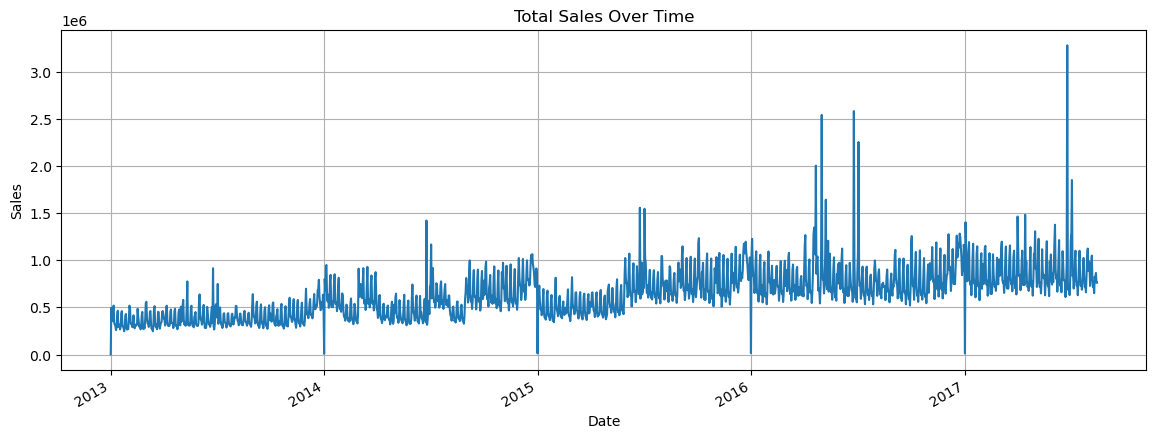

In [38]:
plt.figure(figsize=(14,5))
df.groupby("date")["sales"].sum().plot()
plt.title("Total Sales Over Time")
plt.xlabel("Date")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

#### 2. SALES BY STORE

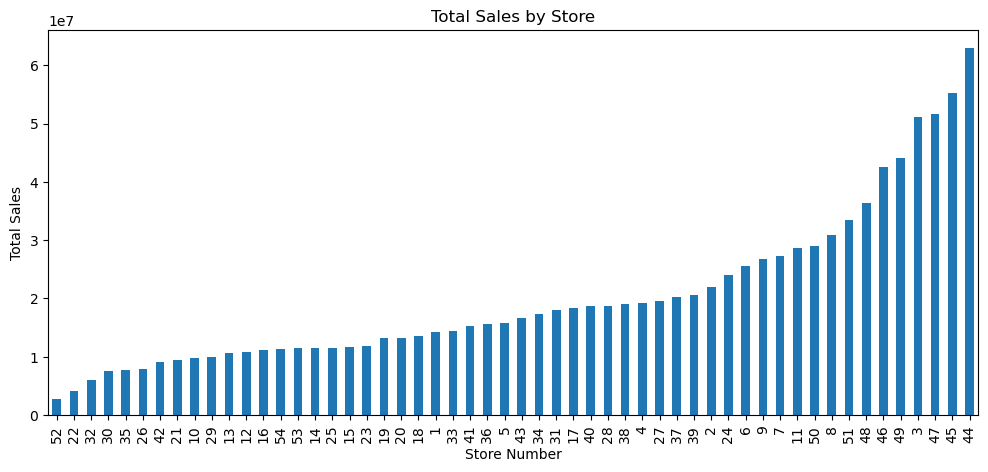

In [40]:
plt.figure(figsize=(12,5))
store_sales = df.groupby("store_nbr")["sales"].sum().sort_values()
store_sales.plot(kind='bar')
plt.title("Total Sales by Store")
plt.xlabel("Store Number")
plt.ylabel("Total Sales")
plt.show()

#### 3. SALES BY PRODUCT FAMILY

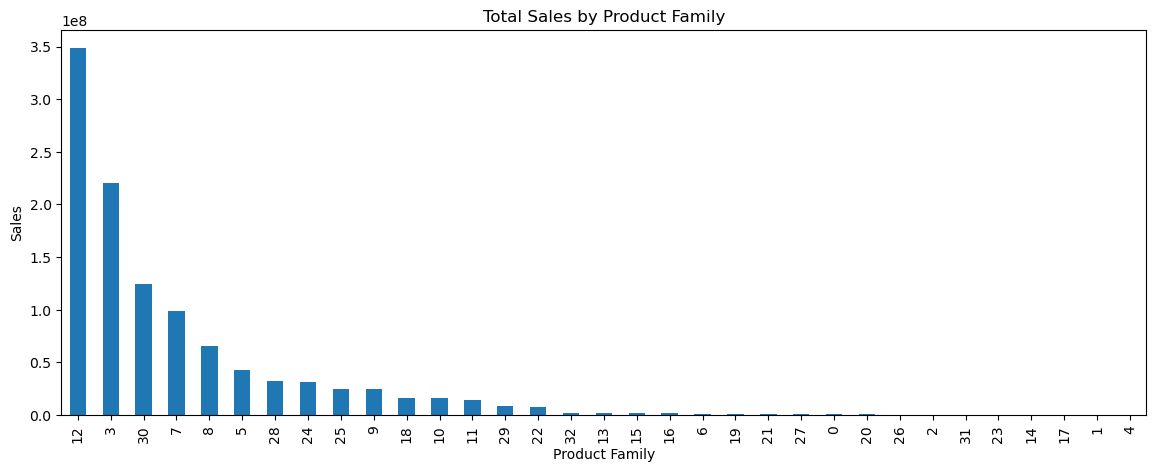

In [42]:
plt.figure(figsize=(14,5))
family_sales = df.groupby("family")["sales"].sum().sort_values(ascending=False)
family_sales.plot(kind='bar')
plt.title("Total Sales by Product Family")
plt.xlabel("Product Family")
plt.ylabel("Sales")
plt.show()

#### 4. HOLIDAY VS NON-HOLIDAY SALES

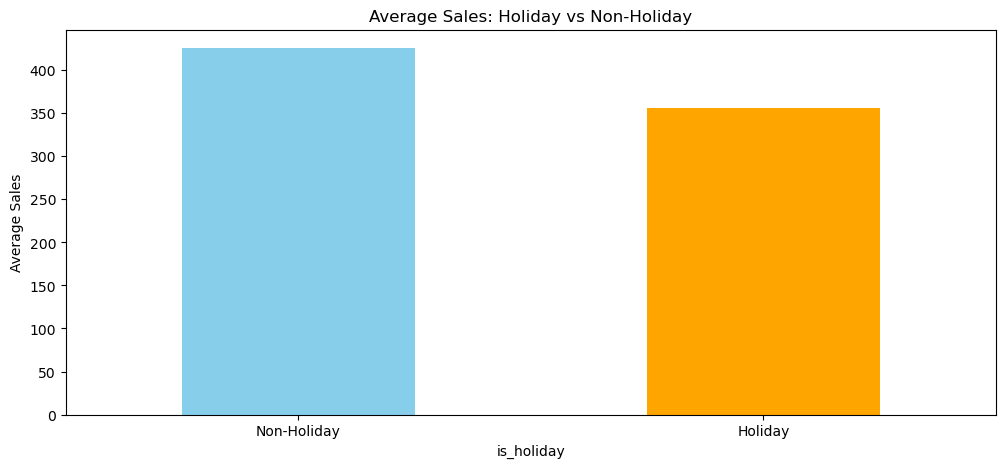

In [44]:
plt.figure(figsize=(12,5))
df["is_holiday"] = (df["holiday_type"] != 0).astype(int)
df.groupby("is_holiday")["sales"].mean().plot(kind="bar", color=["skyblue","orange"])
plt.xticks([0,1], ["Non-Holiday", "Holiday"], rotation=0)
plt.title("Average Sales: Holiday vs Non-Holiday")
plt.ylabel("Average Sales")
plt.show()

#### 5. WEEKLY SALES PATTERN

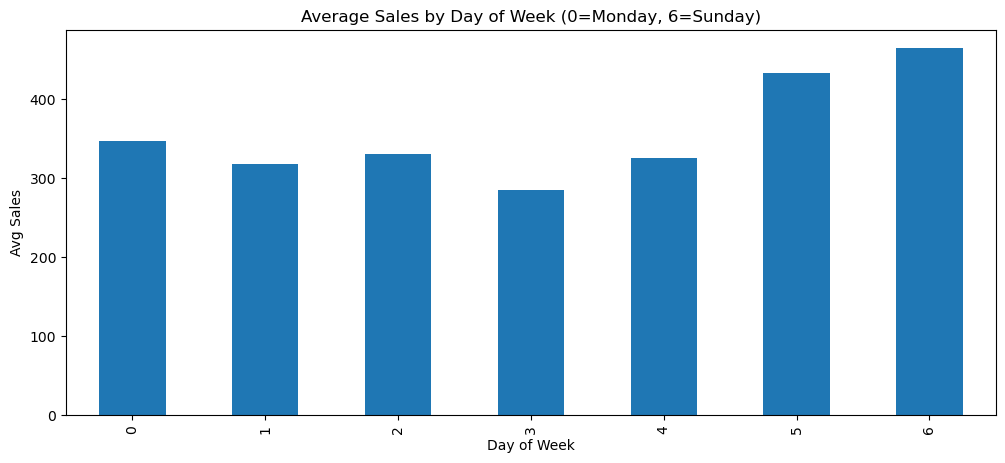

In [46]:
plt.figure(figsize=(12,5))
df.groupby("day_of_week")["sales"].mean().plot(kind='bar')
plt.title("Average Sales by Day of Week (0=Monday, 6=Sunday)")
plt.xlabel("Day of Week")
plt.ylabel("Avg Sales")
plt.show()

#### 6. MONTHLY SALES PATTERN

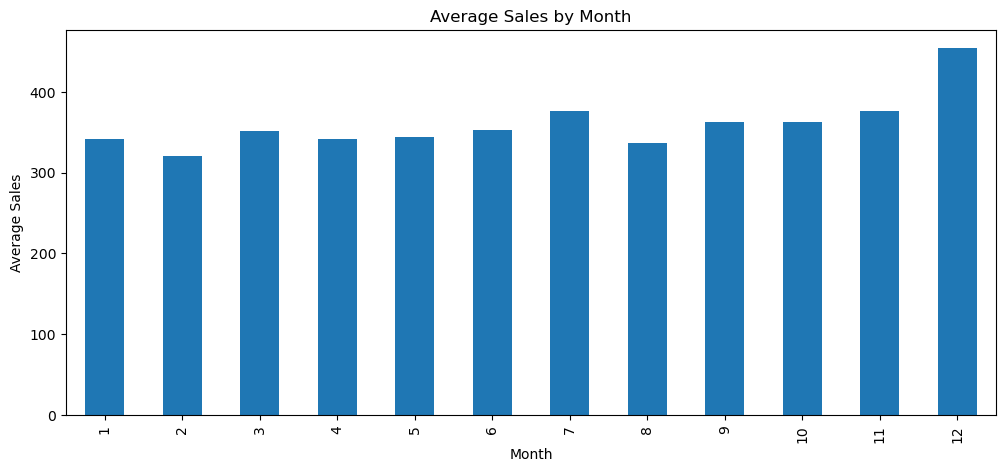

In [48]:
plt.figure(figsize=(12,5))
df.groupby("month")["sales"].mean().plot(kind='bar')
plt.title("Average Sales by Month")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

#### 7. OIL PRICE RELATIONSHIP

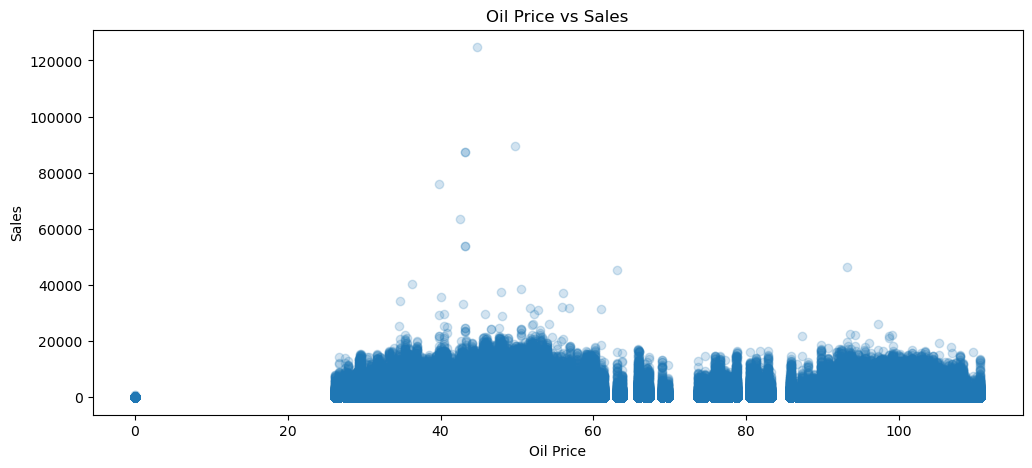

In [50]:
plt.figure(figsize=(12,5))
plt.scatter(df['dcoilwtico'], df['sales'], alpha=0.2)
plt.title("Oil Price vs Sales")
plt.xlabel("Oil Price")
plt.ylabel("Sales")
plt.show()

#### 8. CORRELATION HEAT MAP 

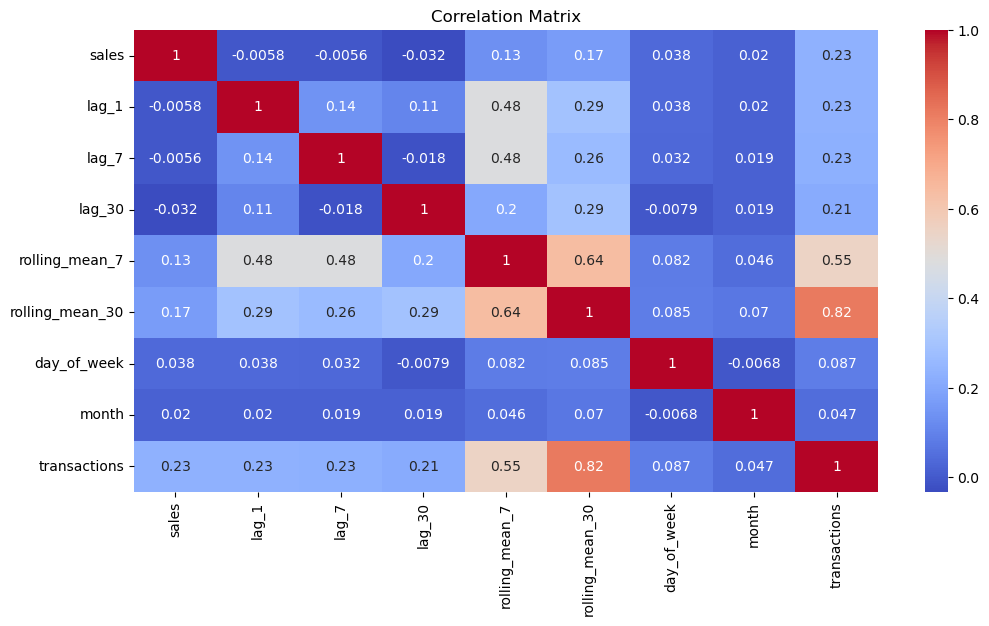

In [145]:
plt.figure(figsize=(12,6))
sns.heatmap(df[['sales','lag_1','lag_7','lag_30','rolling_mean_7','rolling_mean_30',
                    'day_of_week','month','transactions']].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

### STEP 6 - TRAIN-TEST SPLIT
For time series forecasting, we must NOT shuffle the data.
We split based on date:
- Train: 2013 → 2016
- Test: Jan 2017 → Aug 2017

In [52]:
# Sort by store and date
df = df.sort_values(["store_nbr", "date"]).reset_index(drop=True)

# Split date for train/test
train_df = df[df['date'] < '2017-01-01']
test_df  = df[df['date'] >= '2017-01-01']

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

# Define features for ML
features = [
    'year','month','day','day_of_week','week_of_year','day_of_year',
    'is_weekend','is_month_start','is_month_end',
    'lag_1','lag_7','lag_30','rolling_mean_7','rolling_mean_30',
    'type','family','cluster','transactions','dcoilwtico','holiday_type','holiday_locale','holiday_locale_name'
]

target = 'sales'

# Example check
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]

print("Feature sample:")
X_train.head()

Train shape: (2628450, 30)
Test shape:  (411642, 30)
Feature sample:


,year,month,day,day_of_week,week_of_year,day_of_year,is_weekend,is_month_start,is_month_end,lag_1,...,rolling_mean_7,rolling_mean_30,type,family,cluster,transactions,dcoilwtico,holiday_type,holiday_locale,holiday_locale_name
0,2013,1,1,1,1,1,0,1,0,0.0,...,0.0,0.0,3,0,13,0.0,0.0,1,1,4
1,2013,1,1,1,1,1,0,1,0,0.0,...,0.0,0.0,3,1,13,0.0,0.0,1,1,4
2,2013,1,1,1,1,1,0,1,0,0.0,...,0.0,0.0,3,2,13,0.0,0.0,1,1,4
3,2013,1,1,1,1,1,0,1,0,0.0,...,0.0,0.0,3,3,13,0.0,0.0,1,1,4
4,2013,1,1,1,1,1,0,1,0,0.0,...,0.0,0.0,3,4,13,0.0,0.0,1,1,4


### STEP 7 - MODELING
We will:
- Train 4 models
- Predict on test data
- Evaluate with RMSE, MAE, MAPE
- Store results for comparison

In [54]:
def mean_absolute_percentage_error(y_true, y_pred): 
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    y_true = np.where(y_true==0, 1, y_true)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

results = {}

#### 1. LINEAR REGRESSION

In [56]:
lr = LinearRegression(n_jobs=-1)
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)

results["Linear Regression"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, lr_pred)),
    "MAE": mean_absolute_error(y_test, lr_pred),
    "MAPE": mean_absolute_percentage_error(y_test, lr_pred)
}

#### 2. LASSO REGRESSION

In [58]:
lasso = Lasso(alpha=0.1, max_iter=2000)
lasso.fit(X_train[:200000], y_train[:200000])   # SAMPLE to 2 lakh
lasso_pred = lasso.predict(X_test)

results["Lasso"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred)),
    "MAE": mean_absolute_error(y_test, lasso_pred),
    "MAPE": mean_absolute_percentage_error(y_test, lasso_pred)
}

#### 3. RANDOM FOREST REGRESSOR

In [60]:
rf = RandomForestRegressor(
    n_estimators=50,      # Reduced from 200
    max_depth=10,         # Reduced from 15
    n_jobs=-1,
    random_state=42
)

rf.fit(X_train[:300000], y_train[:300000])      # Train on 3 lakh samples only
rf_pred = rf.predict(X_test)

results["Random Forest"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "MAE": mean_absolute_error(y_test, rf_pred),
    "MAPE": mean_absolute_percentage_error(y_test, rf_pred)
}

#### 4. XGBOOST REGRESSOR

In [62]:
xgb = XGBRegressor(
    n_estimators=100,     # Reduced from 300
    max_depth=6,          # Reduced from 8
    learning_rate=0.1,
    subsample=0.7,
    colsample_bytree=0.7,
    n_jobs=-1,
    tree_method="approx"  # FASTEST method
)

xgb.fit(X_train[:300000], y_train[:300000])     # 3 lakh sample training
xgb_pred = xgb.predict(X_test)

results["XGBoost"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, xgb_pred)),
    "MAE": mean_absolute_error(y_test, xgb_pred),
    "MAPE": mean_absolute_percentage_error(y_test, xgb_pred)
}

#### 5. SHOW RESULTS

In [64]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('RMSE')
results_df

,RMSE,MAE,MAPE
XGBoost,440.810134,158.506675,1231.510806
Random Forest,441.793156,140.223120,341.092077
Linear Regression,1291.755970,640.233288,11293.251828
Lasso,1316.337887,774.100178,15744.771206


### STEP 8 - MODEL COMPARISON & BEST MODEL SELECTION
We will:
- Compare model performance.
- Identify the best model (lowest RMSE).
- Save the best model for future predictions.
- Prepare the model for forecasting.

In [66]:
print("Model Performance Comparison:\n")
display(results_df)

# Select best model (lowest RMSE)
best_model_name = results_df['RMSE'].idxmin()
best_model_name

Model Performance Comparison:



,RMSE,MAE,MAPE
XGBoost,440.810134,158.506675,1231.510806
Random Forest,441.793156,140.223120,341.092077
Linear Regression,1291.755970,640.233288,11293.251828
Lasso,1316.337887,774.100178,15744.771206


'XGBoost'

#### FETCH ACTUAL MODEL OBJECT

In [68]:
model_dict = {
    "Linear Regression": lr,
    "Lasso": lasso,
    "Random Forest": rf,
    "XGBoost": xgb
}

best_model = model_dict[best_model_name]
best_model

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=-1, num_parallel_tree=None, ...)

### STEP 9 - GENERATE FUTURE FORECASTING FOR 30 DAYS
We will:
- Create future 30 days’ date range.
- Generate same features as training data.
- Merge store, oil, and holiday info.
- Use the best model to predict.
- Produce a final forecast table.

#### 1. CREATE NEXT 30 DAYS

In [71]:
last_date = df['date'].max()

future_dates = pd.date_range(start=last_date + pd.Timedelta(days=1), periods=30)
future_df = pd.DataFrame({"date": future_dates})
# future_df

#### 2. GET ALL STORES NUMBERS

In [73]:
all_stores = df["store_nbr"].unique()

future_full = (
    future_df.assign(key=1)
    .merge(pd.DataFrame({"store_nbr": all_stores, "key": 1}), on="key")
    .drop("key", axis=1)
)
# future_full

#### 3. MERGE OIL DATA

In [75]:
future_full = future_full.merge(oil[["date", "dcoilwtico"]], on="date", how="left")

# Forward fill missing oil values
future_full["dcoilwtico"] = future_full["dcoilwtico"].fillna(method="ffill")
# future_full

#### 4. MERGE HOLIDAY DATA

In [77]:
# Clean holiday data
holidays['date'] = pd.to_datetime(holidays['date'], format="mixed", dayfirst=True)

# Everything except 'Work Day' is a holiday
holidays['is_holiday'] = holidays['holiday_type'].apply(
    lambda x: 0 if x.lower() == "event" else 1
)

# Keep only required fields
holidays_small = holidays[['date', 'is_holiday']]

future_full = future_full.merge(holidays_small, on="date", how="left")
future_full["is_holiday"] = future_full["is_holiday"].fillna(0)

# future_full

#### 5. MERGE STORE METADATA

In [79]:
future_full = future_full.merge(stores, on="store_nbr", how="left")

# future_full

#### 6. FEATURE ENGINEERING

In [81]:
future_full["year"] = future_full["date"].dt.year
future_full["month"] = future_full["date"].dt.month
future_full["day"] = future_full["date"].dt.day
future_full["dayofweek"] = future_full["date"].dt.dayofweek

# future_full

#### 7. ONE-HOT ENCODING

In [83]:
future_full = pd.get_dummies(future_full, columns=["state", "cluster"], drop_first=True)

# future_full

#### 8. ALIGN COLUMNS WITH TRAINING

In [85]:
# Add missing columns
for col in X_train.columns:
    if col not in future_full:
        future_full[col] = 0

# Keep only train columns
future_full = future_full[X_train.columns]

In [86]:
future_full['type'] = le.fit_transform(future_full['type']) # make the type column as integer, earlier it was object
# future_full.info() 
# future_full.select_dtypes(include='object').columns

#### 9. PREDICTION

In [88]:
future_full["forecast"] = best_model.predict(future_full)
# Restore store_nbr column because it got removed during feature selection
future_full["store_nbr"] = np.tile(all_stores, len(future_dates))

#### 10. FINAL FORECAST OUTPUT

In [170]:
forecast_output = future_full.copy()
forecast_output["date"] = future_dates.repeat(len(all_stores))

forecast_output = forecast_output[["date", "forecast"]]

forecast_output.head()

,date,forecast
0,2017-08-16,65.587265
1,2017-08-16,65.587265
2,2017-08-16,65.587265
3,2017-08-16,65.587265
4,2017-08-16,65.587265


In [184]:
forecast_output_mean = forecast_output.groupby('date', as_index=False)['forecast'].mean()
forecast_output_mean